In [1]:
import os
import joblib
import json

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score

import numpy as np
import matplotlib.pyplot as plt

import torch

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [3]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = True      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

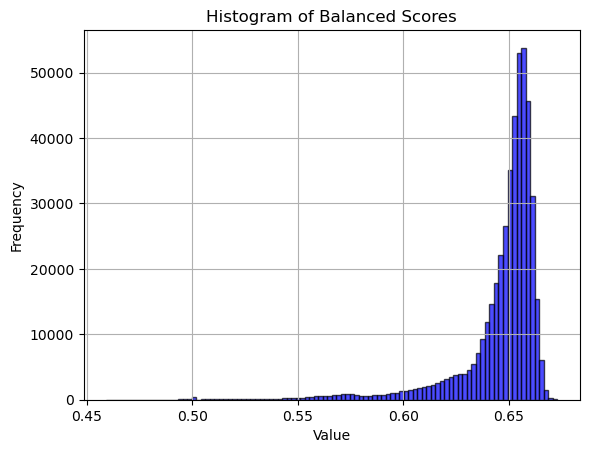

In [4]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

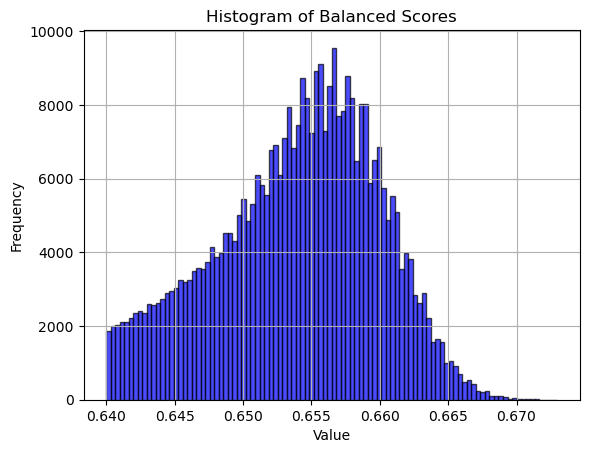

In [5]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [6]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attack

In [ ]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

/home/jose/anaconda3/envs/obfuscation/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jose/anaconda3/envs/obfuscation/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

NameError: name 'X_test' is not defined